# 项目 6：图像增强可视化

**目标**：把「数据增强」从名词变成眼前看得见的图——一张图，经过各种增强变成十几张「长得像但不一样」的图。

**你已经知道了**：旋转、翻转、裁剪、颜色抖动这些名词。这个 notebook 让你**亲眼看到**每种增强到底做了什么。

**为什么这很重要**：后面「无监督（SimCLR）」和「半监督（FixMatch）」的增强，原理都建立在「同一张图的不同增强 = 同一个东西」这个点上。先看懂增强，才能看懂后面。

> 数据已准备好（CIFAR-10 测试集 1 万张，32×32 彩色图），直接跑。

图像数据形状: (10000, 32, 32, 3)
标签形状: (10000,)


c:\Users\D\.conda\envs\pytorch_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29483 (\N{CJK UNIFIED IDEOGRAPH-732B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\pytorch_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 33337 (\N{CJK UNIFIED IDEOGRAPH-8239}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\pytorch_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 39134 (\N{CJK UNIFIED IDEOGRAPH-98DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\pytorch_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26426 (\N{CJK UNIFIED IDEOGRAPH-673A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\pytorch_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 38738 (\N{CJK UNIFIE

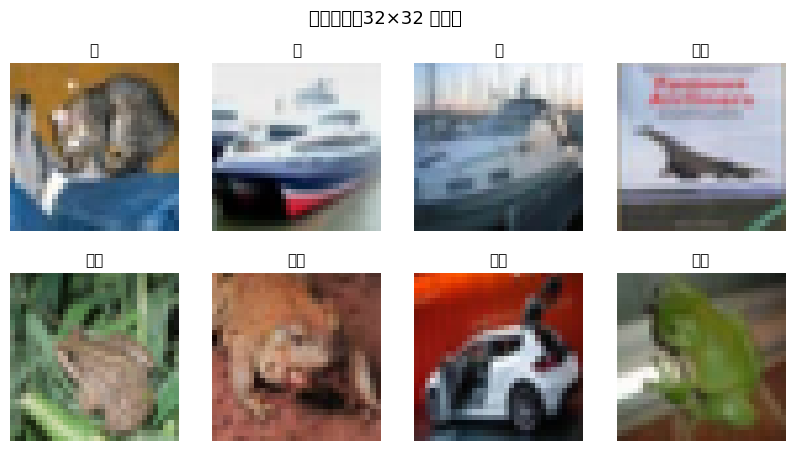

In [1]:
# 第 1 步：加载数据 + 看看原图
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T

# 加载准备好的数据（已经存成 .npy）
X = np.load(r"D:\machine_learning\data\cifar10_test_images.npy")
y = np.load(r"D:\machine_learning\data\cifar10_test_labels.npy")

# CIFAR-10 的 10 个类别
classes = ["飞机", "汽车", "鸟", "猫", "鹿", "狗", "青蛙", "马", "船", "卡车"]

print("图像数据形状:", X.shape)   # (10000, 32, 32, 3) = 1万张 32×32 彩色图
print("标签形状:", y.shape)

# 展示前 8 张原图
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i])
    ax.set_title(f"{classes[y[i]]}", fontsize=11)
    ax.axis("off")
plt.suptitle("原始图像（32×32 彩色）", fontsize=13)
plt.show()

## 增强分两大类

- **几何变换**：改变「位置/形状」——旋转、翻转、裁剪、缩放（图片内容不变，摆放变了）
- **颜色变换**：改变「颜色」——亮度、对比度、饱和度、色相（位置不变，颜色变了）

下面把一张图用 10 种增强各变一次，画成网格对比。

C:\Users\D\AppData\Local\Temp\ipykernel_35996\1535870804.py:24: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\D\AppData\Local\Temp\ipykernel_35996\1535870804.py:24: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\D\AppData\Local\Temp\ipykernel_35996\1535870804.py:24: UserWarning: Glyph 27700 (\N{CJK UNIFIED IDEOGRAPH-6C34}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\D\AppData\Local\Temp\ipykernel_35996\1535870804.py:24: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\D\AppData\Local\Temp\ipykernel_35996\1535870804.py:24: UserWarning: Glyph 32763 (\N{CJK UNIFIED IDEOGRAPH-7FFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\D\AppData\Local\Temp\ipykernel_35996\1535870804.py:24: UserWarning: Glyph 36716 (\N{CJK UNIFIED IDEOGRAPH-

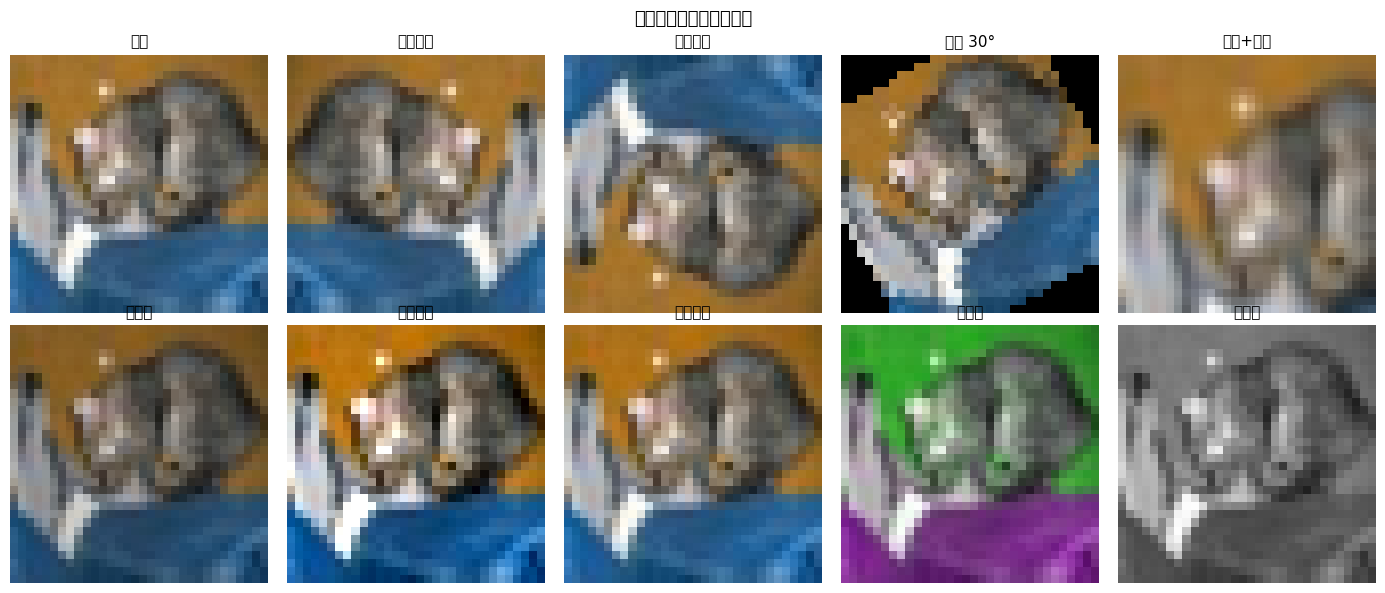

In [2]:
# 第 2 步：核心 —— 同一张图的 10 种增强效果
img = Image.fromarray(X[0])   # 挑第一张（飞机），numpy 转成 PIL 图

# 定义一个「增强菜单」，每项是一个 transform
transforms_dict = {
    "原图":            T.Compose([]),
    "水平翻转":        T.RandomHorizontalFlip(p=1.0),
    "垂直翻转":        T.RandomVerticalFlip(p=1.0),
    "旋转 30°":        T.RandomRotation(degrees=(30, 30)),
    "裁剪+放大":       T.RandomResizedCrop(size=32, scale=(0.5, 0.5)),
    "调亮度":          T.ColorJitter(brightness=0.8),
    "调对比度":        T.ColorJitter(contrast=0.8),
    "调饱和度":        T.ColorJitter(saturation=0.8),
    "调色相":          T.ColorJitter(hue=0.3),
    "转灰度":          T.Grayscale(num_output_channels=3),
}

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, (name, t) in zip(axes.flat, transforms_dict.items()):
    ax.imshow(t(img))
    ax.set_title(name, fontsize=11)
    ax.axis("off")
plt.suptitle("同一张图的各种增强效果", fontsize=13)
plt.tight_layout()
plt.show()

## 增强是「随机」的 —— 这是它最关键的属性

注意上面的增强都叫 `Random...`。意味着**每次调用结果都不同**。

下面用同一个「颜色抖动」，跑 6 次，得到 6 张**不同的**图。

这正是增强能「无限扩充数据」的原因：训练时每个 epoch（每一轮）看到的都是图片的**新版本**，模型永远「看不腻」，就不会死记硬背原图 → 防过拟合。

c:\Users\D\.conda\envs\pytorch_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\pytorch_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 27425 (\N{CJK UNIFIED IDEOGRAPH-6B21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\pytorch_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\pytorch_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 39068 (\N{CJK UNIFIED IDEOGRAPH-989C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D\.conda\envs\pytorch_env\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 25238 (\N{CJK UNIFIE

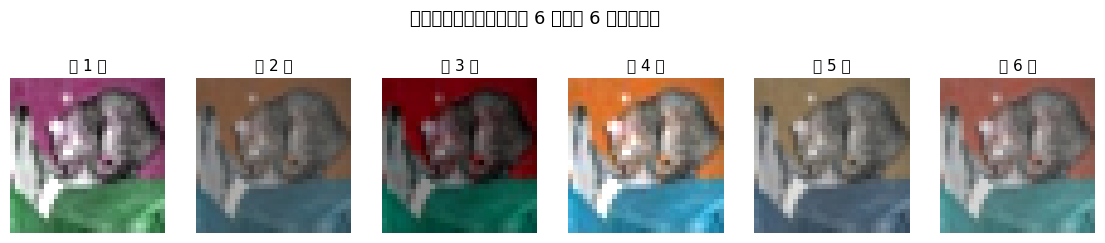

In [3]:
# 第 3 步：展示增强的「随机性」
jitter = T.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.2)

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for i, ax in enumerate(axes):
    ax.imshow(jitter(img))
    ax.set_title(f"第 {i+1} 次", fontsize=11)
    ax.axis("off")
plt.suptitle("同一个颜色抖动增强，跑 6 次得到 6 张不同的图", fontsize=13)
plt.show()

## 自己动手改（练习）

1. 把 `X[0]`（飞机）换成别的图，比如 `X[3]`（猫）、`X[8]`（船），增强效果有什么不同？哪种图对「颜色抖动」更敏感？
2. **组合增强**：用 `T.Compose` 把「旋转 + 水平翻转 + 颜色抖动」串起来，一次同时做三种，看效果：
   ```python
   combo = T.Compose([
       T.RandomRotation(degrees=20),
       T.RandomHorizontalFlip(p=1.0),
       T.ColorJitter(brightness=0.5, saturation=0.5),
   ])
   plt.imshow(combo(img))
   ```
3. **核心理解题**：为什么「随机」是增强的关键？如果增强是「确定」的（每次结果都一样），还能防过拟合吗？

## 看懂这个，你就站在了 SimCLR / FixMatch 的门口

记住下面这句话，它就是后面「无监督 + 增强」的全部秘密：

> **同一张图，做两次不同的增强，得到的两张图「看起来不一样」，但本质上是同一个东西。**

- 无监督（SimCLR）抓住这点，让模型学「这俩是同一个东西」→ 学会图像特征
- 半监督（FixMatch）抓住这点，让模型对「同一张图的两次增强」给出一样的预测 → 用无标注数据

下一课见。